# Zadanie domowe

W przypadku obrazów w odcieniach szarości pojedynczy piksel z zakresu [0; 255] reprezentowany jest jako 8-bitowa liczba bez znaku.
Pewnym rozszerzeniem analizy sposobu reprezentacji obrazu może być następujący eksperyment.
Załóżmy, że z każdego z 8 bitów możemy stworzyć pojedynczy obraz binarny (ang. _bit-plane slicing_).
Dla obrazka _100zloty.jpg_ (https://raw.githubusercontent.com/vision-agh/poc_sw/master/02_Point/100zloty.jpg) stwórz 8 obrazów, z których każdy powinien zawierać jedną płaszczyznę bitową.
Podpowiedź $-$ warto sprawdzić, jak realizuje się bitowe operacje logiczne.
Zastosowanie takiej dekompozycji obrazu pozwala na analizę ,,ważności'' poszczególnych bitów.
Jest to użyteczne w kwantyzacji, ale także w kompresji.

W drugim etapie zadania proszę spróbować odtworzyć obraz oryginalny z mniejszej liczby obrazów binarnych.
Warto zacząć od dwóch najbardziej znaczących bitów, a później dodawać kolejne.
Należy utworzyć co najmniej trzy wersje zrekonstruowanych obrazów.
Podpowiedź $-$ rekonstrukcja obrazu to mnożenie przez odpowiednią potęgę liczby 2 (przesunięcie bitowe) oraz dodawanie.

In [ ]:
import cv2
import os
import requests
import matplotlib.pyplot as plt

url = 'https://raw.githubusercontent.com/vision-agh/poc_sw/master/02_Point/'
fileName = '100zloty.jpg'
if not os.path.exists(fileName) :
    r = requests.get(url + fileName, allow_redirects=True)
    open(fileName, 'wb').write(r.content)

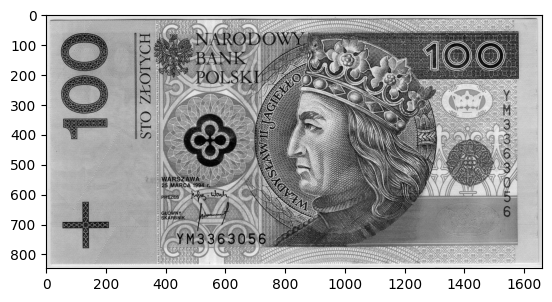

In [ ]:
im = cv2.imread('100zloty.jpg')
im = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)
plt.imshow(im,cmap='gray')
plt.show()

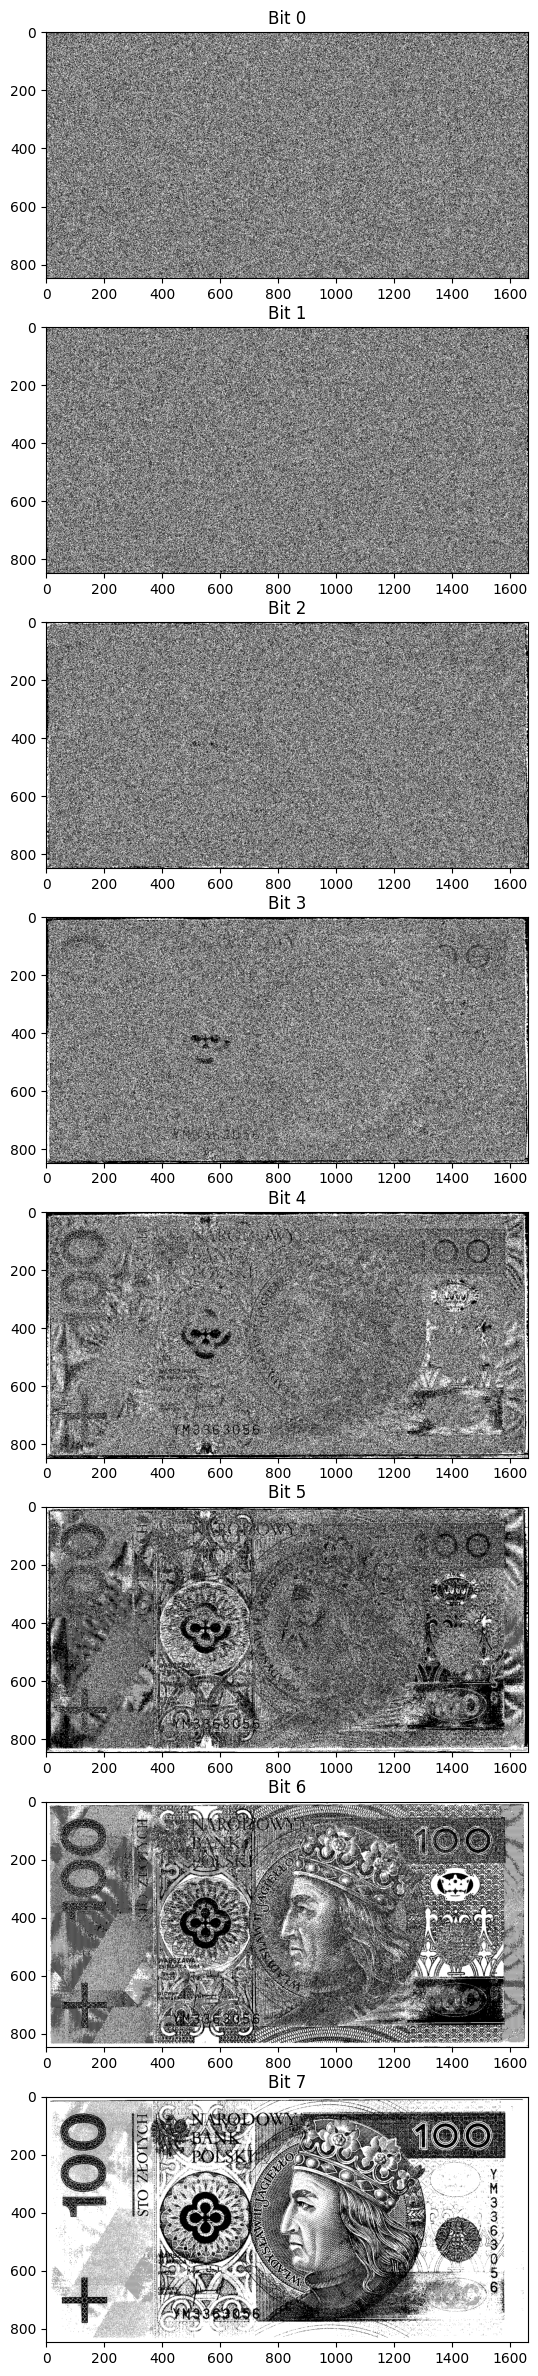

In [ ]:
fig, axs = plt.subplots(8, 1, figsize=(30, 30))
bit_ims = []

for (ax, bit) in zip(axs.flatten(), range(0,8)):
  mul = im & 2**bit
  bit_ims.append(mul.astype('bool').astype('uint8'))
  ax.imshow(mul,cmap='gray')
  ax.set_title(f'Bit {bit}')


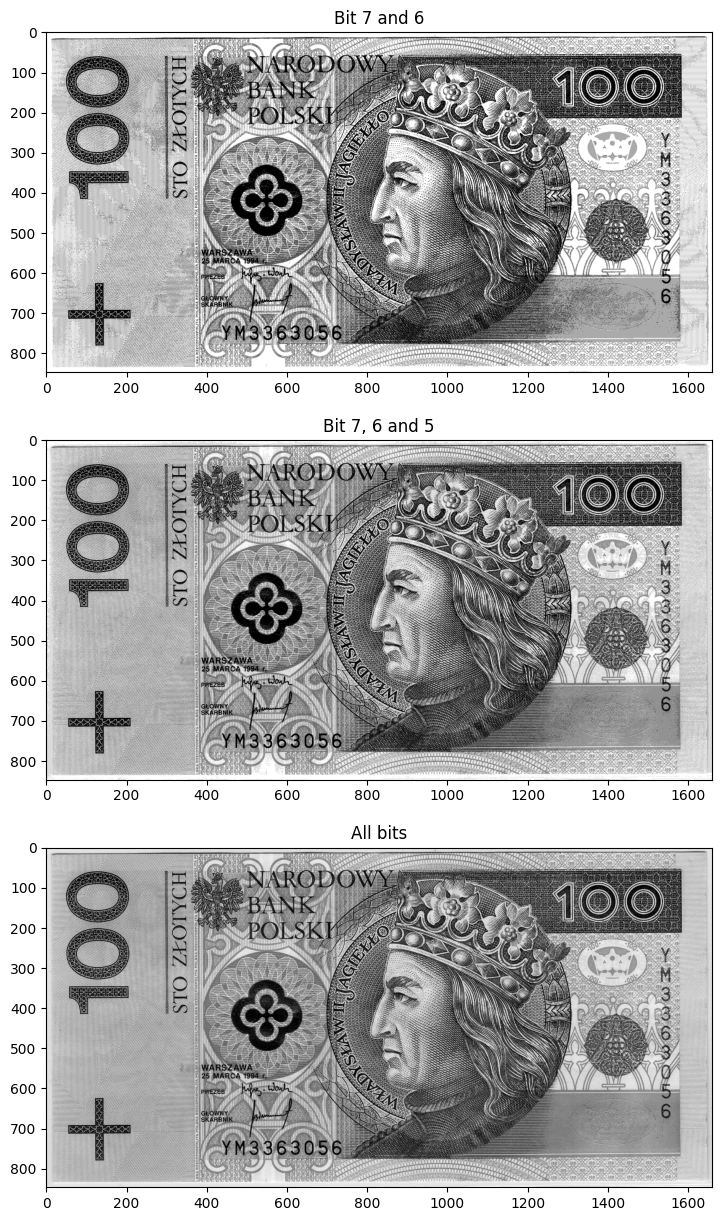

In [ ]:
fig, axs = plt.subplots(3, 1, figsize=(15, 15))

axs[0].set_title('Bit 7 and 6')
combined = bit_ims[7]*2**7 + bit_ims[6]*2**6
axs[0].imshow(combined,cmap='gray')

axs[1].set_title('Bit 7, 6 and 5')
combined = bit_ims[7]*2**7 + bit_ims[6]*2**6 + bit_ims[5]*2**5
axs[1].imshow(combined,cmap='gray')

axs[2].set_title('All bits')
combined_last = sum( bit_ims[i] * 2**i for i in range(0,8))
axs[2].imshow(combined_last,cmap='gray')